# SE/CSE 5602 Final Project

#### Group 4: Lixuan Zhao & Evan Schulze

We have selected the Crossed Barrel dataset to reproduce for this project.

__Reference Paper__: Liang Q et al. (2021). _Benchmarking the performance of Bayesian optimization across multiple experimental materials science domains._ npj Computational Materials 7, 188.

__Reference data repository__: https://github.com/PV-Lab/Benchmarking

Read in libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from multiprocessing import Pool
from parallelbar import progress_starmap

Read in Crossed Barrel dataset and average repeated points from triplication process:

In [39]:
df = pd.read_csv('Crossed barrel_dataset.csv')

# Average repeated points as part of triplication process
features = ['n', 'theta', 'r', 't']
label = 'toughness'
df_avg = df.groupby(features)[label].mean().reset_index()

# Verify results
print(f"Original data points: {len(df)}")
print(f"Averaged data points: {len(df_avg)}")

# Save cleaned dataset
df_avg.to_csv('crossed_barrel_averaged.csv', index=False)
print("Averaging complete. Saved to 'crossed_barrel_averaged.csv'.")

Original data points: 1800
Averaged data points: 600
Averaging complete. Saved to 'crossed_barrel_averaged.csv'.


### Data Visualization

The first step is to visualize the data to understand what we are working with.

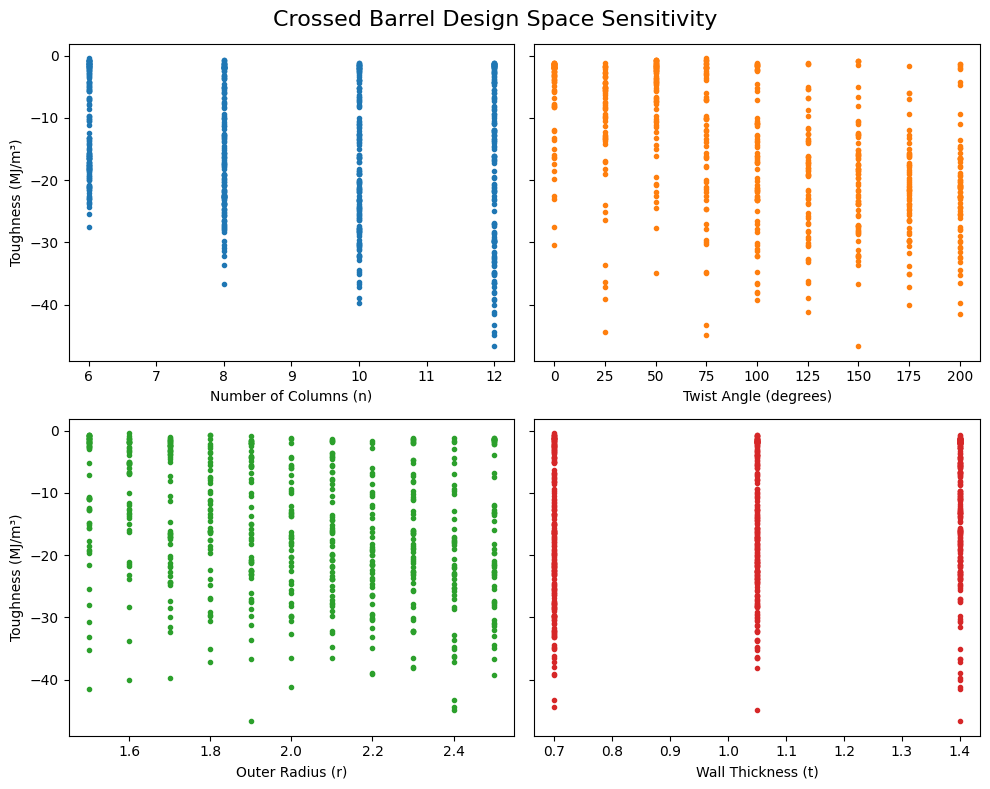

In [36]:
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(10, 8),sharey=True)

# Subplot 1: Number of Columns
axes[0,0].plot(df_avg.n, df_avg.toughness,'.',color='tab:blue')
axes[0,0].set_xlabel('Number of Columns (n)')
axes[0,0].set_ylabel('Toughness (MJ/m³)')

# Subplot 2: Twist Angle
axes[0,1].plot(df_avg.theta, df_avg.toughness,'.',color='tab:orange')
axes[0,1].set_xlabel('Twist Angle (degrees)')

# Subplot 3: Outer Radius
axes[1,0].plot(df_avg.r, df_avg.toughness,'.',color='tab:green')
axes[1,0].set_xlabel('Outer Radius (r)')
axes[1,0].set_ylabel('Toughness (MJ/m³)')

# Subplot 4: Wall Thickness
axes[1,1].plot(df_avg.t, df_avg.toughness,'.',color='tab:red')
axes[1,1].set_xlabel('Wall Thickness (t)')

fig.suptitle('Crossed Barrel Design Space Sensitivity', fontsize=16)
plt.tight_layout()
plt.show()

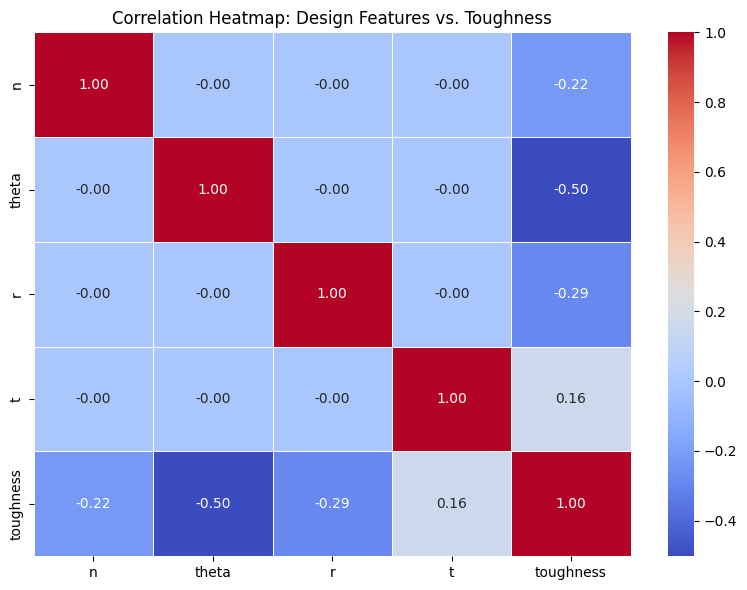

<Figure size 1200x1000 with 0 Axes>

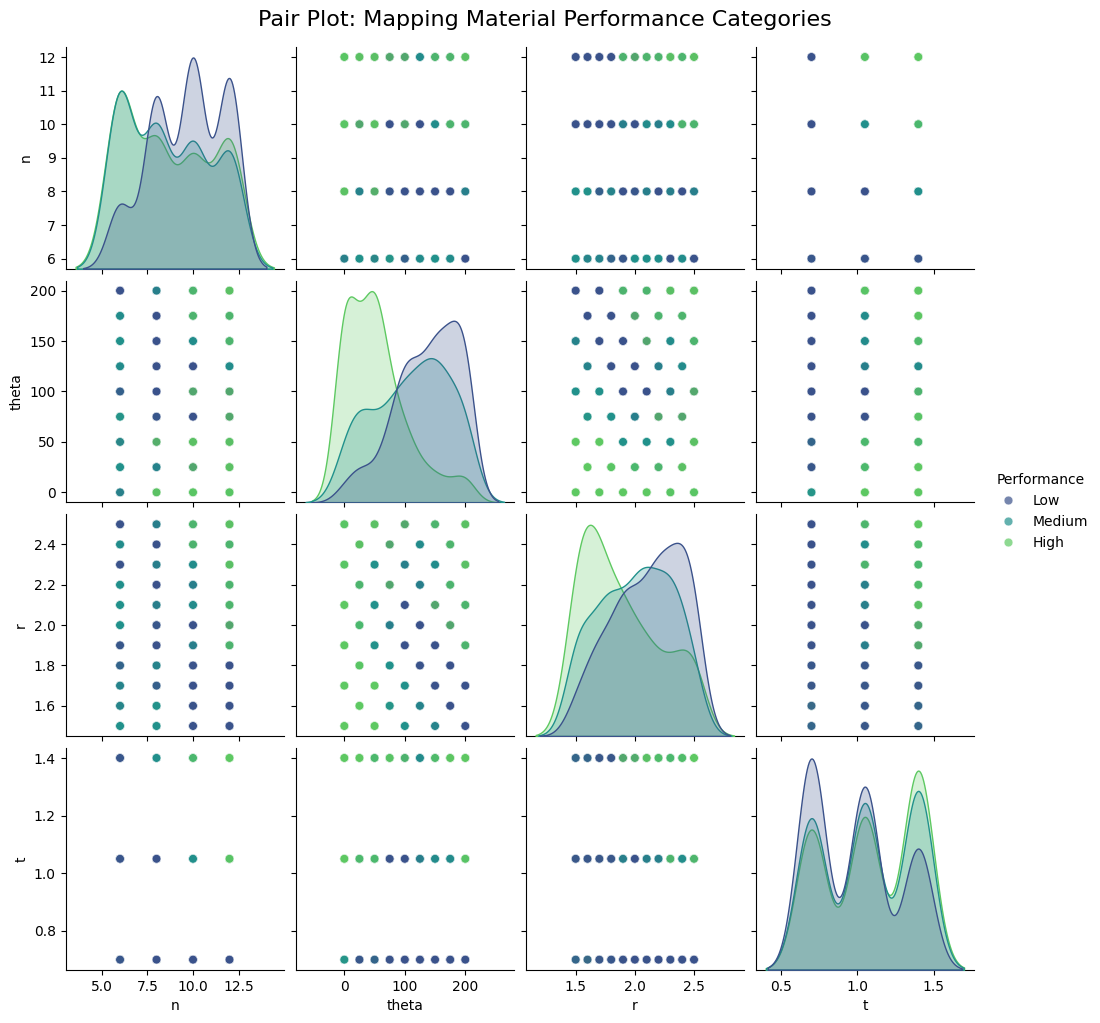

In [37]:
# Create a categorical column based on Toughness. 
# q=3 splits the data into three equal groups (tertiles).
df_avg['Performance'] = pd.qcut(df_avg['toughness'], q=3, labels=['Low', 'Medium', 'High'])

# Correlation Heatmap
plt.figure(figsize=(8, 6))
# Only correlate the numeric design features and the target label
numeric_cols = ['n', 'theta', 'r', 't', 'toughness']
correlation_matrix = df_avg[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Design Features vs. Toughness')
plt.tight_layout()
plt.show()

# Pair Plot
# Color-code (hue) by the 'Performance' category.
# Drop 'toughness' from the variables to focus on the 4 design dimensions - toughness is covered in the 'Performance' category.
plt.figure(figsize=(12, 10))
pair_grid = sns.pairplot(
    df_avg.drop(columns=['toughness']), 
    hue='Performance', 
    palette='viridis', # 'viridis' is great for color-blind friendliness
    diag_kind='kde',   # Smooth distributions on the diagonal
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'w', 'linewidth': 0.5}
)

pair_grid.fig.suptitle('Pair Plot: Mapping Material Performance Categories', y=1.02, fontsize=16)
plt.show()

### BO Model

This section will be where we attempt to reporduce the results from the paper using a Random Forests active-learning model.

First, define the function that will run the BO optimization:

In [5]:
def run_bo_optimization(df, iterations=100, kappa=2.0, sd=42):
    # Internal imports for parallel computing
    import numpy as np
    import pandas as pd
    from sklearn.ensemble import RandomForestRegressor

    # Initialize data pool
    datapool = df.copy()
    
    # Using the seed for the initial random selection to ensure trial variety
    np.random.seed(sd)
    observed_indices = list(np.random.choice(datapool.index, size=2, replace=False))
    
    results = []
    
    # Tell user that a new trial started
    print(f"Trial Seed: {sd}")
    
    for i in range(iterations):
        # Split data into training and candidates pools
        train_df = datapool.loc[observed_indices]
        candidate_df = datapool.drop(observed_indices)
        
        X_train = train_df[['n', 'theta', 'r', 't']]
        y_train = train_df['toughness']
        
        # RF surrogate model
        rf = RandomForestRegressor(
            n_estimators=150, 
            max_features=1.0, 
            min_samples_leaf=1,
            bootstrap=True,
            random_state=sd,
            n_jobs=1
        )
        rf.fit(X_train, y_train)
        
        # Uncertainty estimation
        X_pool = candidate_df[['n', 'theta', 'r', 't']]
        all_tree_preds = np.stack([tree.predict(X_pool.values) for tree in rf.estimators_])
        mu = all_tree_preds.mean(axis=0)
        sigma = all_tree_preds.std(axis=0)
        
        # Apply Acquisition Function (LCB)
        lcb_scores = mu - (kappa * sigma)
        best_candidate_idx = candidate_df.index[np.argmin(lcb_scores)]
        
        # Identify next candidate
        observed_indices.append(best_candidate_idx)
        
        # Track progress (multiplying by -1 to show real toughness)
        current_best = train_df['toughness'].min() * -1
        results.append(current_best)

        # Progress Tracker: Prints every 20 steps
        if (i + 1) % 100 == 0:
             print(f"      [Seed {sd}] Step {i+1}/{iterations} | Best Toughness: {current_best:.4f}")

    print(f"--- [Seed {sd}] COMPLETE ---")
    return results

Next, we set up the data and run it through the BO function as a test. This involves multiplying the toughness by -1 to formulate this into a minimization problem, per Liang et al.

In [6]:
# Formulate into minimization problem
if df_avg.toughness[0] > 0:
    df_avg["toughness"]=df_avg["toughness"]*-1

# Test run through BO optimization function
bo_progress = run_bo_optimization(df_avg)

Trial Seed: 42
      [Seed 42] Step 100/100 | Best Toughness: 44.9449
--- [Seed 42] COMPLETE ---


It works! Now time to put it in a test loop with many random_states to get an average model performance metric.

In [30]:
# Set up experiment
n_runs =  50   # number of trial runs to test
n_iter = 500   # number of iteratiomns per run
K = 2.0        # Kappa, AKA "lambda", from LCB acquisition function

In [8]:
# Leverage parallel computing to speed up model run time:

if __name__ == '__main__':
   
    # Generate unique seeds
    seeds = np.random.choice(1000, size=n_runs, replace=False)
    args = [(df_avg, n_iter, K, seed) for seed in seeds]
    
    print(f"Starting parallel execution of {n_runs} trials...")

    # Parallel computing...
    with Pool() as pool:
        results_list = progress_starmap(run_bo_optimization, args, n_cpu=8, need_serialize=True, chunk_size=1)

    # Post-Processing
    all_results = np.array(results_list)
    final_values = all_results[:, -1]

    # Aggregate result curves
    mean_result = all_results.mean(axis=0)
    std_result = all_results.std(axis=0)

    # Aggregate result final values
    mean_value = final_values.mean()
    std_value = final_values.std()

    print(f"\nAll trials complete.")

Starting parallel execution of 50 trials...


DONE:   0%|          | 0/50 [00:00<?, ?it/s]


All trials complete.


In [9]:
# Old code prior to changing to parallel computing:

# # "n_runs" random starting seeds
# seeds = np.random.choice(1000, size=n_runs, replace=False)

# all_results = []
# ii = 0
# for seed in seeds:
#     ii+=1
#     print(f"Iteration #{ii}, seed: {seed}")
#     result_curve = run_bo_optimization(
#         df_avg,
#         iterations = n_iter,
#         kappa = K,
#         sd = seed)
#     all_results.append(result_curve)

# all_results = np.array(all_results)
# final_values = all_results[:,-1]

# # Aggregate result curves
# mean_result = all_results.mean(axis=0)
# std_result = all_results.std(axis=0)

# # Aggregate result final values
# mean_value = final_values.mean()
# std_value = final_values.std()

In [10]:
# Print final results
print(f"Mean final best toughness: {mean_value:.4f}")
print(f"Std final best toughness:  {std_value:.4f}")

Mean final best toughness: 46.7114
Std final best toughness:  0.0000


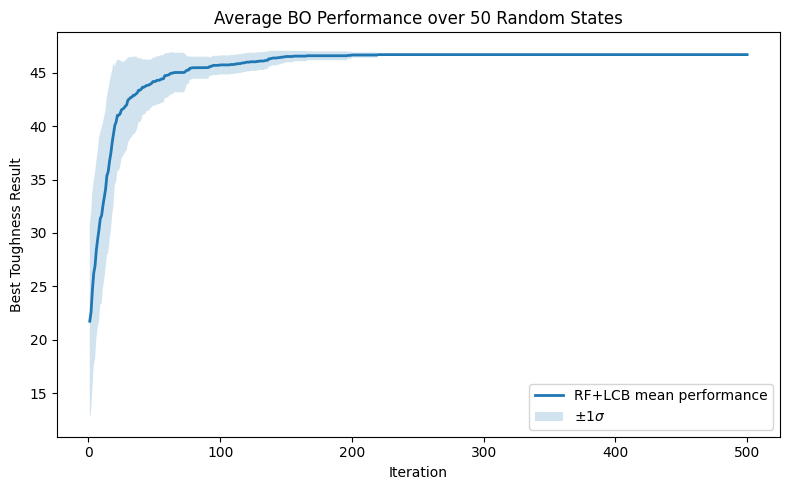

In [11]:
# Plot resulting curves
x = np.arange(1,n_iter+1)

plt.figure(figsize=(8,5))
plt.plot(x,mean_result,label="RF+LCB mean performance", linewidth=2)
plt.fill_between(
    x,
    mean_result - std_result,
    mean_result + std_result,
    alpha=0.2,
    label=r"±1$\sigma$"
)

plt.xlabel("Iteration")
plt.ylabel("Best Toughness Result")
plt.title(f"Average BO Performance over {n_runs} Random States")
plt.legend()
plt.tight_layout()
plt.show()

### Random Sampling Baseline Model

Now, let's run 50 randomly sampled models to compare as our baseline.

We first created a function to perform a random sampling baseline. After we noticed the performance was not matching the paper, we included the P_rand function from Liang et al.

In [12]:
def run_random_trial(df, iterations=100):
    """
    Simulates one random sampling trial.
    Returns the cumulative minimum (best performance) at each iteration.
    """
    # 1. Randomly sample toughness values without replacement
    samples = df['toughness'].sample(n=iterations, replace=False).values
    
    # 2. Calculate the 'Best Found So Far' at every step
    best_result = np.minimum.accumulate(samples)*-1
    
    return best_result

In [13]:
# Code from Liang et al.: https://github.com/PV-Lab/Benchmarking/blob/main/Performance%20Visualization.ipynb
def P_rand(nn):
    x_random = np.arange(nn)
    
    M = 0.05*nn
    N = nn
    
    P = np.array([None for i in x_random])
    E = np.array([None for i in x_random])
    A = np.array([None for i in x_random])
    cA = np.array([None for i in x_random])
    
    P[0] = M / N
    E[0] = M / N
    A[0] = M / N
    cA[0] = A[0]
    

    for i in x_random[1:]:
        P[i] = (M - E[i-1]) / (N - i)
        E[i] = np.sum(P[:(i+1)])
        j = 0
        A_i = P[i]
        while j < i:
            A_i *= (1 - P[j])
            j+=1
        A[i] = A_i
        cA[i] = np.sum(A[:(i+1)])
        
    return E / M, cA

In [31]:
# Run all trials and store in a list of arrays
baseline_results = [run_random_trial(df_avg, n_iter) for _ in range(n_runs)]
baseline_matrix = np.array(baseline_results)

# Average model performance
mean_baseline = np.mean(baseline_matrix, axis=0)
std_baseline = np.std(baseline_matrix, axis=0)

# Grab final results
final_baseline_results = baseline_matrix[:,-1]

# Aggregate result final values
mean_baseline_value = final_baseline_results.mean()
std_baseline_value = final_baseline_results.std()

In [15]:
# Print final results
print(f"Mean final best toughness: {mean_baseline_value:.4f}")
print(f"Std final best toughness:  {std_baseline_value:.4f}")

Mean final best toughness: 46.5348
Std final best toughness:  0.5300


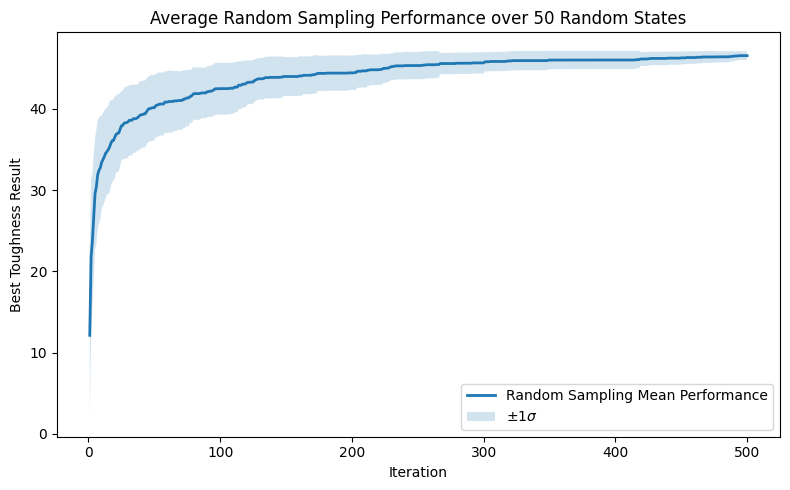

In [16]:
# Plot resulting curves
plt.figure(figsize=(8,5))
plt.plot(x,mean_baseline,label="Random Sampling Mean Performance", linewidth=2)
plt.fill_between(
    x,
    mean_baseline - std_baseline,
    mean_baseline + std_baseline,
    alpha=0.2,
    label=r"±1$\sigma$"
)

plt.xlabel("Iteration")
plt.ylabel("Best Toughness Result")
plt.title(f"Average Random Sampling Performance over {n_runs} Random States")
plt.legend()
plt.tight_layout()
plt.show()

### Compare Metrics

First, let's just look at raw performance.

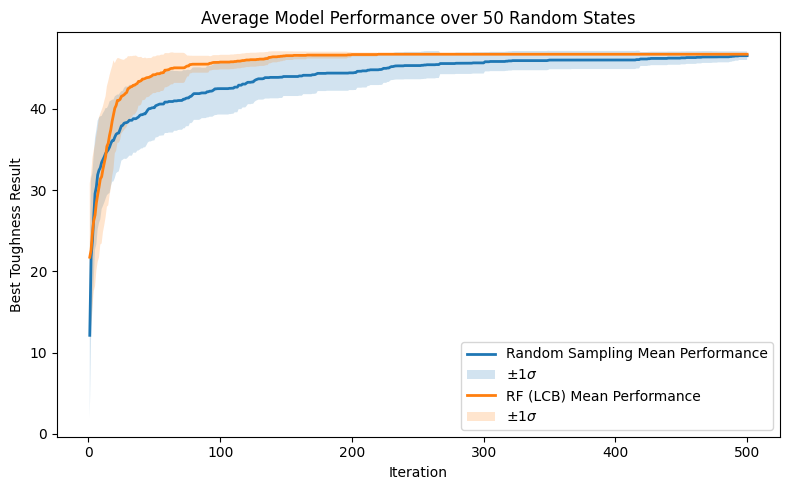

In [17]:
plt.figure(figsize=(8,5))

# Plot Random Sampling performance
plt.plot(x,mean_baseline,label="Random Sampling Mean Performance", linewidth=2)
plt.fill_between(
    x,
    mean_baseline - std_baseline,
    mean_baseline + std_baseline,
    alpha=0.2,
    label=r"±1$\sigma$"
)

# Plot BO performance
plt.plot(x,mean_result,label="RF (LCB) Mean Performance", linewidth=2)
plt.fill_between(
    x,
    mean_result - std_result,
    mean_result + std_result,
    alpha=0.2,
    label=r"±1$\sigma$"
)

plt.xlabel("Iteration")
plt.ylabel("Best Toughness Result")
plt.title(f"Average Model Performance over {n_runs} Random States")
plt.legend()
plt.tight_layout()
plt.show()

Now, let's calculate metrics for each method.

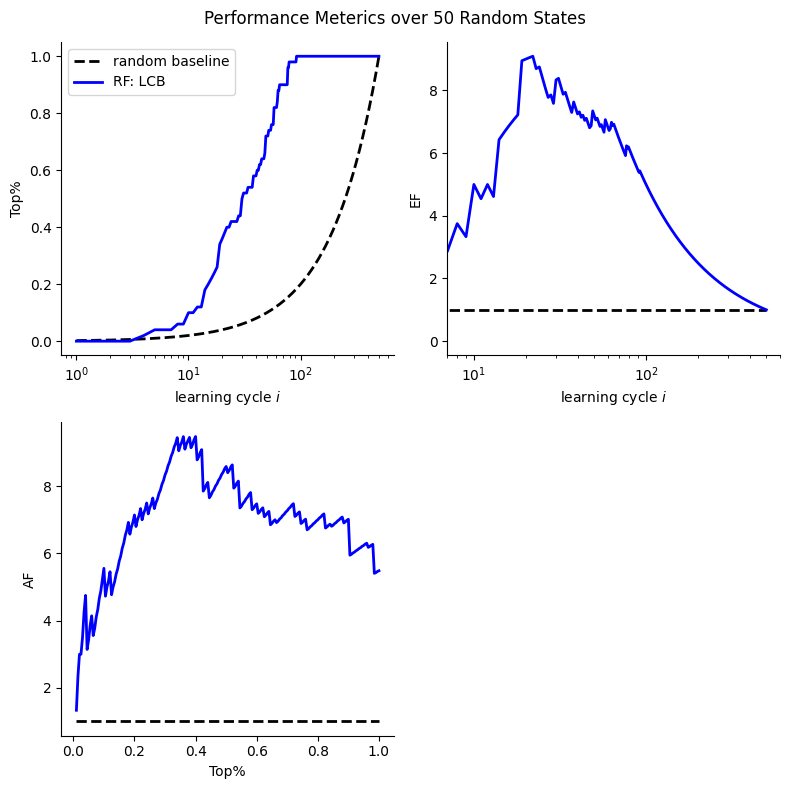

In [38]:
# Get max and min from dataset, but remember that toughness is inversed!
data_max = df_avg['toughness'].min()*-1
data_min = df_avg['toughness'].max()*-1

# Using Liang et al. code:
rand_baseline = P_rand(n_iter)[0]

rand_baseline_switch = 0 # 1 = our random baseline, 0 = Liang et al. random baseline

# Top%:
percent_threshold = 0.05 
target_value = data_max-(percent_threshold*(data_max-data_min))
top_perc_bo = []
top_perc_baseline = []
for ii in range(n_iter):
    temp_bo = all_results[:,ii]
    top_perc_bo.append(np.sum(temp_bo >= target_value)/n_runs)
    temp_baseline = baseline_matrix[:,ii]
    top_perc_baseline.append(np.sum(temp_baseline >= target_value)/n_runs)

top_perc_bo = np.array(top_perc_bo)
if rand_baseline_switch:
    top_perc_baseline = np.array(top_perc_baseline)
else:
    top_perc_baseline = rand_baseline

# EF
if rand_baseline_switch:
    EF_bo = top_perc_bo/top_perc_baseline
else:
    EF_bo = top_perc_bo/rand_baseline

# AF
top_perc_range = np.arange(0.01,1.005,0.005)
accel_bo = []
accel_baseline = []
for t in top_perc_range:
    accel_bo.append(np.where(top_perc_bo >= t)[0][0])
    if rand_baseline_switch:
        accel_baseline.append(np.where(top_perc_baseline >= t)[0][0])
    else:
        accel_baseline.append(np.where(rand_baseline >= t)[0][0])

accel_bo = np.array(accel_bo)
accel_baeline = np.array(accel_baseline)
AF_bo = accel_baseline/accel_bo

# Replicate plots (a), (b), and (c) from Liang et al.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

# axes[0,0].plot(x,rand_baseline,label='random baseline',linewidth=2,linestyle='dashed',color='gray')
axes[0,0].plot(x,top_perc_baseline,label='random baseline',linewidth=2,linestyle='dashed',color='black')
axes[0,0].plot(x,top_perc_bo,label='RF: LCB',linewidth=2,linestyle='solid',color='blue')
axes[0,0].set_xlabel('learning cycle $\\mathit{i}$')
axes[0,0].set_xscale('log')
# axes[0,0].set_xlim(1,600)
axes[0,0].set_ylabel('Top%')
axes[0,0].spines['right'].set_visible(False)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].legend()

axes[0,1].plot(x,np.ones(np.shape(x)),label='random baseline',linewidth=2,linestyle='dashed',color='black')
axes[0,1].plot(x,EF_bo,label='RF: LCB',linewidth=2,linestyle='solid',color='blue')
axes[0,1].set_xlabel('learning cycle $\\mathit{i}$')
axes[0,1].set_xscale('log')
axes[0,1].set_xlim(7,600)
axes[0,1].set_ylabel('EF')
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['top'].set_visible(False)

axes[1,0].plot(top_perc_range,np.ones(np.shape(top_perc_range)),label='random baseline',linewidth=2,linestyle='dashed',color='black')
axes[1,0].plot(top_perc_range,AF_bo,label='RF: LCB',linewidth=2,linestyle='solid',color='blue')
axes[1,0].set_xlabel('Top%')
axes[1,0].set_ylabel('AF')
axes[1,0].spines['right'].set_visible(False)
axes[1,0].spines['top'].set_visible(False)

axes[1,1].set_visible(False)

plt.suptitle(f'Performance Meterics over {n_runs} Random States')
plt.tight_layout()
plt.show()

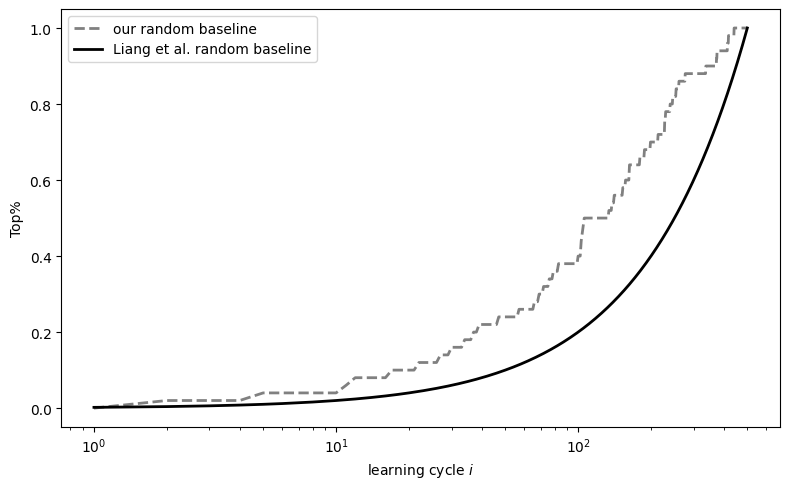

In [34]:
plt.figure(figsize=(8,5))
plt.plot(x,top_perc_baseline,label='our random baseline',linewidth=2,linestyle='dashed',color='gray')
plt.plot(x,rand_baseline,label='Liang et al. random baseline',linewidth=2,linestyle='solid',color='black')
plt.xlabel('learning cycle $\\mathit{i}$')
plt.xscale('log')
plt.ylabel('Top%')
plt.legend()
plt.tight_layout()
plt.show()